[[0.78539816 0.78556489 0.78573166 ... 2.35586099 2.35602777 2.35619449]
 [0.78523144 0.78539816 0.78556494 ... 2.35602771 2.35619449 2.35636121]
 [0.78506466 0.78523139 0.78539816 ... 2.35619449 2.35636127 2.35652799]
 ...
 [2.35652799 2.35636127 2.35619449 ... 0.78539816 0.78523139 0.78506466]
 [2.35636121 2.35619449 2.35602771 ... 0.78556494 0.78539816 0.78523144]
 [2.35619449 2.35602777 2.35586099 ... 0.78573166 0.78556489 0.78539816]]


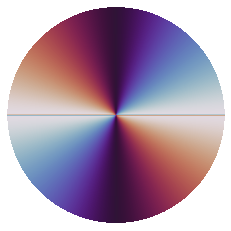

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create a grid of points
x = np.linspace(-1, 1, 6000)
y = np.linspace(-1, 1, 6000)
x, y = np.meshgrid(x, y)

# Create a disk
r = np.sqrt(x**2 + y**2)
disk = np.where(r <= 1, r, np.nan)

# Calculate the angle of each point in the disk
angle = np.arctan2(y, x) % (np.pi)
print(angle)
# Mask the angle array to only include points within the disk
angle = np.where(r <= 1, angle, np.nan)

# Plot the disk with the 'twilight shifted' colormap
plt.imshow(angle, cmap='twilight', origin='lower')
# plt.colorbar(label='angle')
plt.axis('off')  # to hide the axes
plt.savefig('cyclic_colormap.png', dpi = 300, bbox_inches = 'tight')

In [24]:
angle

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

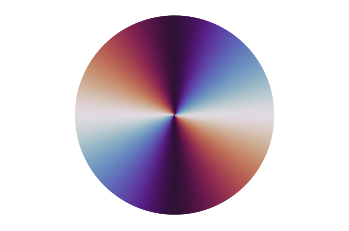

In [35]:
import matplotlib.pyplot as plt
import numpy as np

for r in np.linspace(0, 1, 200):
    # Create an array of angles
    theta = np.linspace(0, 2*np.pi, 2000)

    # Create the points of the circle
    x = np.cos(theta) * r
    y = np.sin(theta) * r

    # Calculate the color of each point based on the angle
    color = theta / (np.pi) % 1  # Normalize the angle to [0, 1]

    # Plot the circle with the 'twilight' colormap
    plt.scatter(x, y, c=color, cmap='twilight', s=0.1)
    plt.axis('equal')  # to ensure the circle isn't distorted
    plt.axis('off')  # to hide the axes
plt.savefig('cyclic_colormap.png', dpi = 300, bbox_inches = 'tight')
    

In [61]:
from PIL import Image

def create_cropped_images(png_path, output_path, num_images, output_size):
    # Open image
    img = Image.open(png_path)
    width, height = img.size

    # Create cropped images
    for i in range(num_images):
        # Calculate crop area
        w = h = min(width, height) / 6 + (min(width, height) / 3) * i / (num_images - 1) + 6
        x = y = 0

        # Crop and resize image
        img_cropped = img.crop((x, y, x + w, y + h))
        img_resized = img_cropped.resize((output_size, output_size))

        # Save image
        img_resized.save(f'{output_path}/{(i):05d}.png')

# Usage
create_cropped_images('tessellation_start.png', 'zoom_out_images', 30, 1000)

### Flatten mesh

In [64]:
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../../Visualization/")
sys.path.append("../../../")

In [65]:
import MeshFEM

In [67]:
m = MeshFEM.Mesh("/Users/yren/Desktop/parametrized_mesh.obj")

In [68]:
import visualization

In [71]:
fusing_data = np.load('/Users/yren/Desktop/fusing_data.npy')

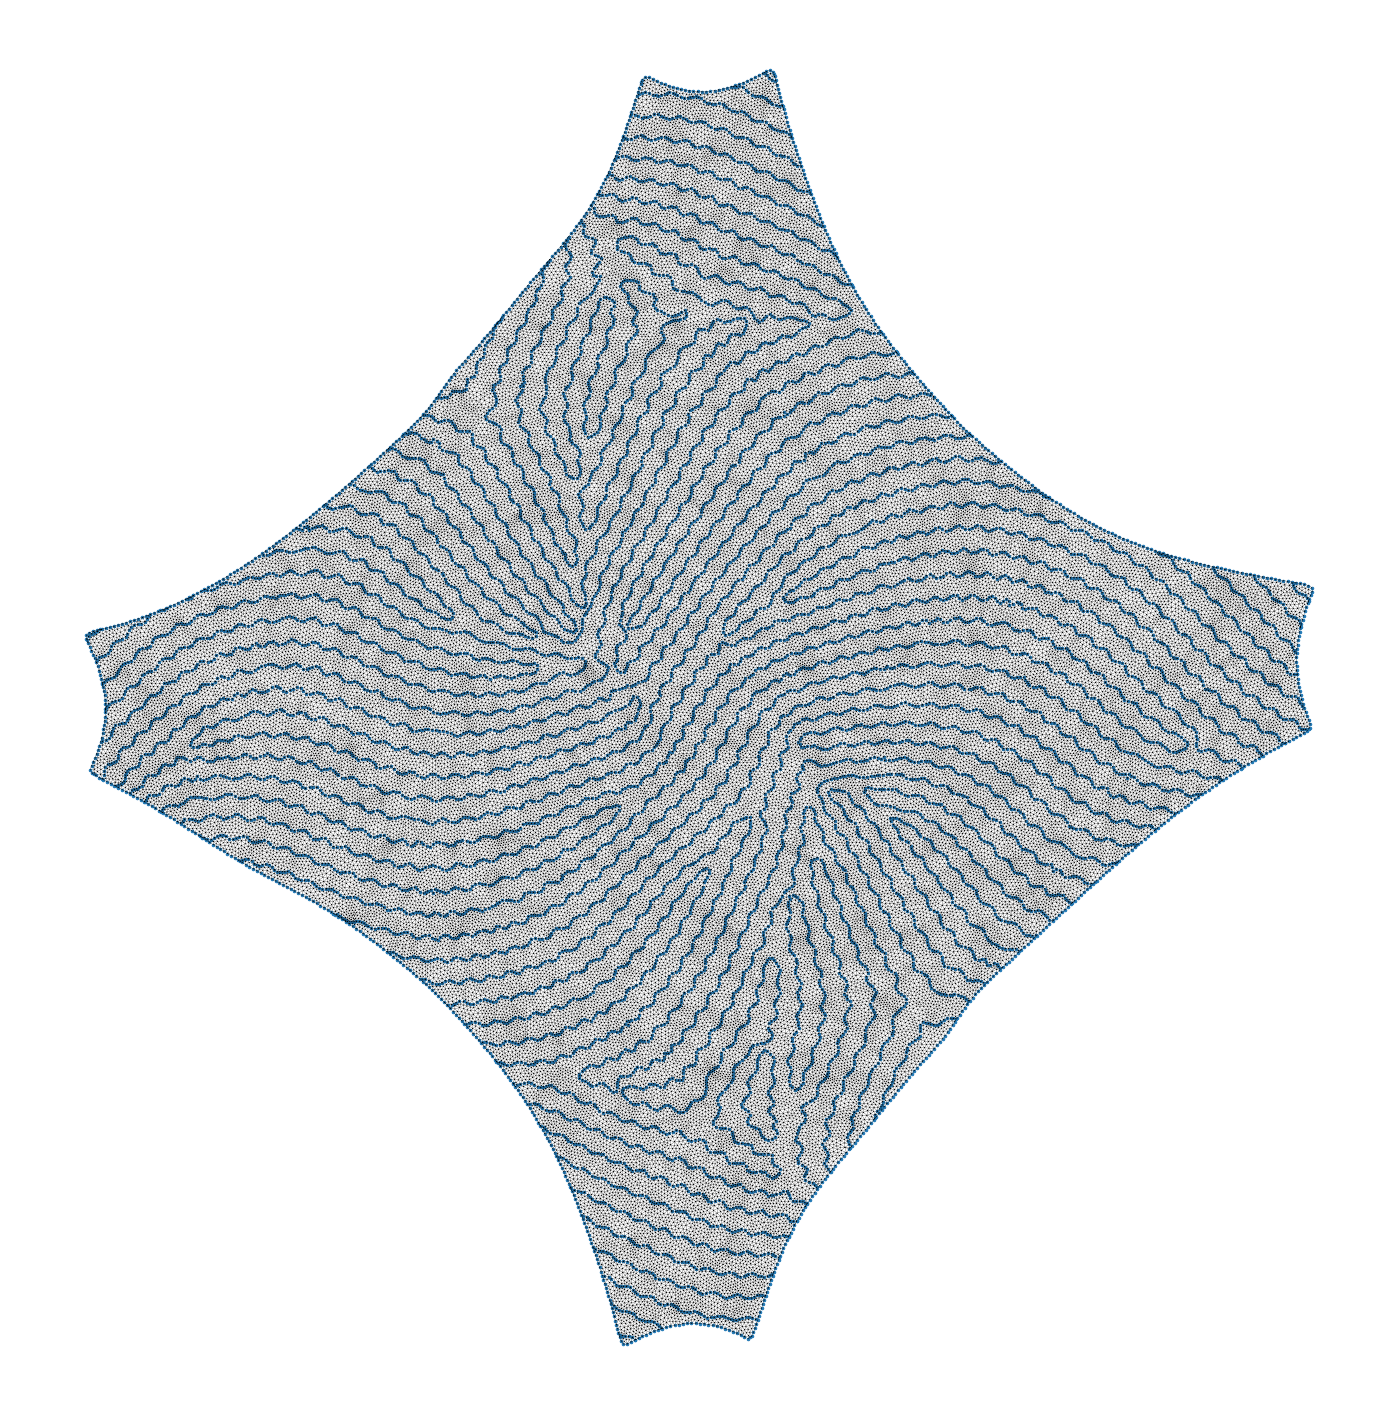

In [75]:
visualization.plot_2d_mesh(m, pointList=fusing_data, width = 20, height = 20)
plt.axis('off')
plt.savefig("/Users/yren/Desktop/mesh_high_res.png", dpi = 500, bbox_inches='tight')